In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.layers import Conv2D,Dense,Flatten,Dropout
from keras.models import Sequential
from tensorflow.keras.datasets import mnist
from keras.callbacks import EarlyStopping

In [2]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()

In [3]:
X_train.ndim

3

In [4]:
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

In [5]:
X_train.ndim

3

In [6]:
model = Sequential()

In [7]:
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))

D:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(optimizer='rmsprop',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [9]:
early = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

In [10]:
history = model.fit(X_train,y_train,epochs=30,batch_size=64,validation_split=0.2,callbacks=[early])

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8724 - loss: 0.4123 - val_accuracy: 0.9556 - val_loss: 0.1508
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9461 - loss: 0.1834 - val_accuracy: 0.9648 - val_loss: 0.1239
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9585 - loss: 0.1438 - val_accuracy: 0.9679 - val_loss: 0.1152
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9647 - loss: 0.1218 - val_accuracy: 0.9727 - val_loss: 0.1017
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9695 - loss: 0.1080 - val_accuracy: 0.9702 - val_loss: 0.1009
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9721 - loss: 0.0985 - val_accuracy: 0.9735 - val_loss: 0.0974
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9746 - loss: 0.0877 - val_accuracy: 0.9752 - val_loss: 0.0911
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9771 - loss: 0.0827 - val_accuracy: 0.

In [11]:
loss,acc = model.evaluate(X_test,y_test)
print('Test Accuracy',acc)
print('Test loss', loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9775 - loss: 0.0843  
Test Accuracy 0.9775000214576721
Test loss 0.08426845818758011


In [15]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

<function matplotlib.pyplot.show(close=None, block=None)>

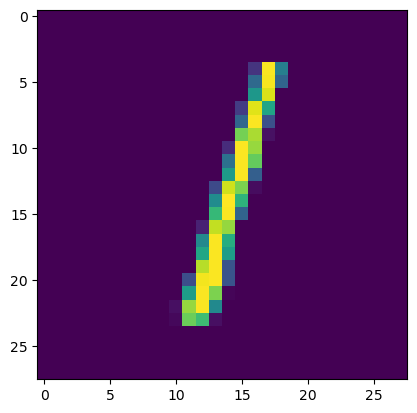

In [21]:
plt.imshow(X_test[2])
plt.show

In [50]:
# Random index choose karo test dataset me se
idx = np.random.randint(0, X_test.shape[0])

# Random image
img = X_test[idx]

# True label
true_label = np.argmax(y_test[idx])


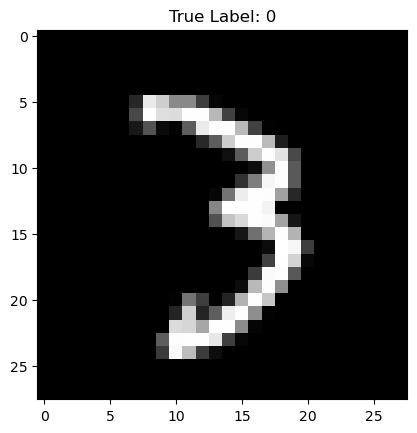

In [51]:
plt.imshow(img, cmap='gray')
plt.title(f"True Label: {true_label}")
plt.show()


In [52]:
# ANN expects 2D array for prediction
img_input = img.reshape(1, 28, 28)  # Flatten already model me hai

# Prediction
pred = model.predict(img_input)

# Predicted label
pred_label = np.argmax(pred)
print("Predicted Label:", pred_label)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted Label: 3


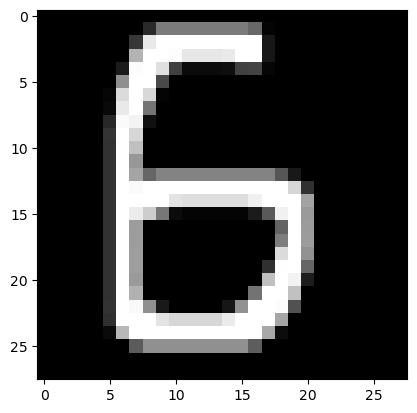

In [57]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Image path
img_path = "Six.png"

# Load image grayscale, resize 28x28
img = Image.open(img_path).convert('L').resize((28,28))

# Convert to numpy array
img_array = np.array(img)

# Normalize like MNIST (0-1)
img_array = img_array / 255.0

# Reshape for model (1 sample)
img_input = img_array.reshape(1, 28, 28)

# Display image
plt.imshow(img_array, cmap='gray')
plt.show()


In [58]:
pred = model.predict(img_input)
pred_label = np.argmax(pred)
print("Predicted Digit: ",pred_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predicted Digit:  3


In [59]:
model.save("my_model.h5")
